## Imports

In [ ]:
# @title
!pip install catboost
!pip install catboost --quiet
!pip install gradio --quiet

import pandas as pd
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn import set_config
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import MinMaxScaler


import warnings
warnings.filterwarnings("ignore")
set_config(transform_output="pandas")

import gradio as gr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.5 MB/s eta 0:00:00


## Data Loading and Initial Inspection

In [ ]:


# Load the dataset from the specified path
df = pd.read_csv('/content/final_crop_dataset_clean.csv')



# Display the first 5 rows of the DataFrame to get a sight of the data
display(df.head())

,lon,lat,bio1,bio12,ph,sand,silt,clay,soc,best_crop
0,48.213810,27.595989,25.751167,115.0,79,421,278,300,31,sorghum
1,41.090602,29.001198,22.198000,96.0,80,379,266,355,66,alfalfa
2,48.390390,21.916444,28.525333,66.0,81,493,357,150,42,date_palm
3,50.993206,21.137445,28.545334,59.0,80,542,321,137,45,date_palm
4,51.566302,22.644760,28.266000,65.0,80,542,317,141,46,date_palm


## Display DataFrame Information

In [ ]:
# Display the concise summary of the DataFrame, including data types and non-null values
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2991 entries, 0 to 2990
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   lon        2991 non-null   float64
 1   lat        2991 non-null   float64
 2   bio1       2991 non-null   float64
 3   bio12      2991 non-null   float64
 4   ph         2991 non-null   int64  
 5   sand       2991 non-null   int64  
 6   silt       2991 non-null   int64  
 7   clay       2991 non-null   int64  
 8   soc        2991 non-null   int64  
 9   best_crop  2991 non-null   object 
dtypes: float64(4), int64(5), object(1)
memory usage: 233.8+ KB


None

## Splitting Data into Training and Test Sets

In [ ]:


# Define the target variable (y) and features (X)
y = df['best_crop']
X = df.drop('best_crop', axis=1)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Display the shapes of the resulting datasets
print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")


Shape of X_train: (2392, 9)
Shape of X_test: (599, 9)
Shape of y_train: (2392,)
Shape of y_test: (599,)


## Encoding and Scaling

In [ ]:

# =============================
# Encode y labels --> numbers
# =============================
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# scaling
scaler = StandardScaler()
X_train_svm_scaled = scaler.fit_transform(X_train)
X_test_svm_scaled = scaler.transform(X_test)

## SVM Model Training and Evaluation(Linear)

In [ ]:
# SVM Model
svm_model1= SVC(kernel="linear")
svm_model1.fit(X_train_svm_scaled, y_train)

# Prediction & Evaluation
svm_preds = svm_model1.predict(X_test_svm_scaled)
svm_acc = accuracy_score(y_test, svm_preds)
svm_report = classification_report(y_test, svm_preds)

print(f"\nSVM Accuracy: {svm_acc:.4f}")
print("\nSVM Classification Report:\n", svm_report)


SVM Accuracy: 0.7629

SVM Classification Report:
               precision    recall  f1-score   support

     alfalfa       0.25      0.05      0.08        40
   date_palm       0.81      0.85      0.83       225
     sorghum       0.80      0.80      0.80       243
       wheat       0.61      0.76      0.68        91

    accuracy                           0.76       599
   macro avg       0.62      0.61      0.60       599
weighted avg       0.74      0.76      0.75       599



## SVM Model Training and Evaluation(Kernal)

In [ ]:
# SVM Model
svm_model2 = SVC(kernel="rbf", gamma='scale', C=1.0)
svm_model2.fit(X_train_svm_scaled, y_train)

# Prediction & Evaluation
svm_preds = svm_model2.predict(X_test_svm_scaled)
svm_acc = accuracy_score(y_test, svm_preds)
svm_report = classification_report(y_test, svm_preds)

print(f"\nSVM Accuracy: {svm_acc:.4f}")
print("\nSVM Classification Report:\n", svm_report)


SVM Accuracy: 0.8497

SVM Classification Report:
               precision    recall  f1-score   support

     alfalfa       0.60      0.23      0.33        40
   date_palm       0.96      0.89      0.92       225
     sorghum       0.84      0.93      0.88       243
       wheat       0.70      0.81      0.76        91

    accuracy                           0.85       599
   macro avg       0.77      0.71      0.72       599
weighted avg       0.85      0.85      0.84       599



## SVM Decision Boundary Visualization

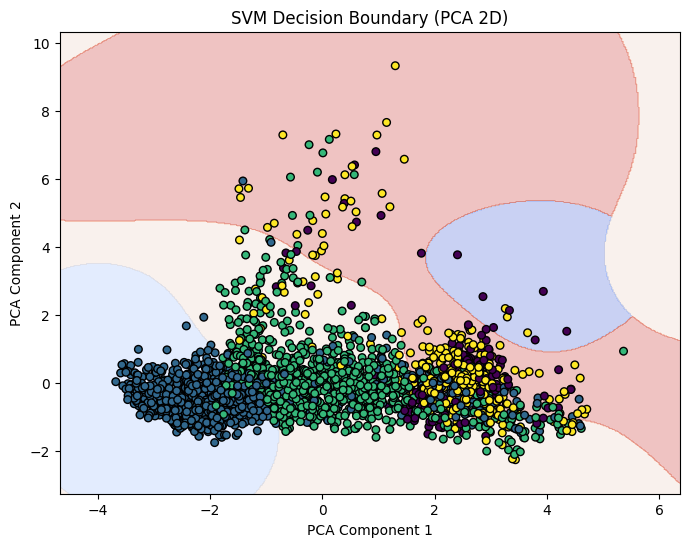

In [ ]:


pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_svm_scaled)
X_test_2d = pca.transform(X_test_svm_scaled)


svm_2d = SVC(kernel=svm_model2.kernel, C=svm_model2.C, gamma=svm_model2.gamma)
svm_2d.fit(X_train_2d, y_train_enc)


xx, yy = np.meshgrid(
    np.linspace(X_train_2d.iloc[:,0].min()-1, X_train_2d.iloc[:,0].max()+1, 500),
    np.linspace(X_train_2d.iloc[:,1].min()-1, X_train_2d.iloc[:,1].max()+1, 500)
)

# التوقعات على الشبكة
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# الرسم
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_train_2d.iloc[:,0], X_train_2d.iloc[:,1], c=y_train_enc, edgecolors='k', s=30)
plt.title("SVM Decision Boundary (PCA 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

## SVM (RBF) Permutation Importance

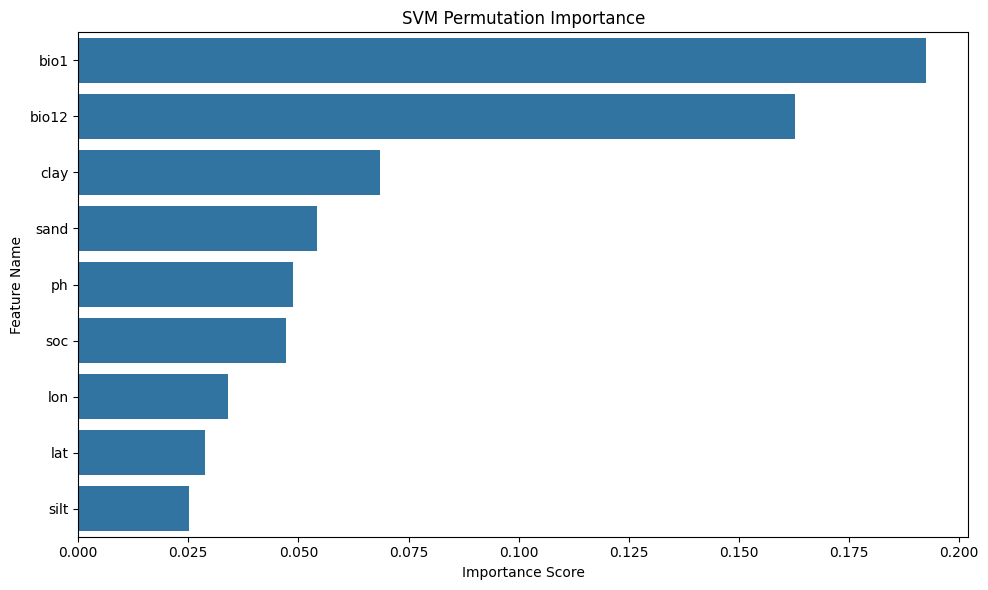

In [ ]:

X2 = X_test_svm_scaled # بعد السكيل
y2 = y_test

# حساب الأهمية
result = permutation_importance(
    svm_model2,
    X2,
    y2,
    n_repeats=10,
    random_state=42,
    scoring='accuracy'
)
# استخراج القيم
importances = result.importances_mean


feature_names_for_plot = X2.columns

importance_df = pd.DataFrame({
    'Feature': feature_names_for_plot,
    'Importance': importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)


plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('SVM Permutation Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

#  SVM Confusion Matrix Visualization

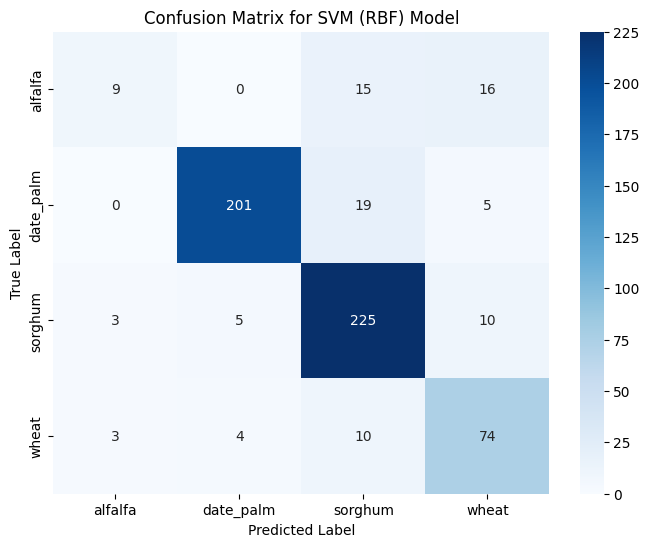

In [ ]:


y_pred_labels2 = svm_model2.predict(X_test_svm_scaled)

cm = confusion_matrix(y_test, y_pred_labels2)

class_labels = le.inverse_transform(sorted(list(set(y_test_enc))))

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=class_labels,yticklabels=class_labels)
plt.title('Confusion Matrix for SVM (RBF) Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()





## CatBoost Model Training and Evaluation

### 2) Why CatBoost Outperformed

**Ordered Boosting:** Reduces target leakage by permuting samples during gradient calculation, preventing overfitting on small datasets (~3k rows).

**Symmetric Trees:**  Stable splits reduce sensitivity to noise and efficiently capture simple feature interactions.

**Strong Defaults & Regularization:** Balanced learning rate, L2, and subsampling work well without heavy tuning.

**Handling Missing Values & Feature Interactions:** Automatically manages missing values and non-linear relationships.

**Partial Robustness to Class Imbalance:** More stable than other boosting methods with unbalanced targets.

**Good for Small/Medium Data:** Boosting reduces bias gradually, capturing subtle patterns better than bagging (Random Forest).

---

### 3) Comparison with Other Models

* Decision Tree: High variance, prone to overfitting → weak test performance.
* Random Forest: Reduces variance but less effective at lowering bias.
* Gradient Boosting: Good but slower and needs tuning.
* XGBoost: Powerful but requires careful tuning; no ordered boosting → less benefit on small datasets.
* CatBoost: Strong “out of the box” performance with minimal tuning.

In [ ]:

#Tree_based Models
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(
        eval_metric='logloss',
        verbosity=0
    ),
    # CatBoost سيستخدم البيانات الأصلية (X الأصلية + y بدون ترميز)
    "CatBoost": CatBoostClassifier(
        logging_level='Silent'
    )
}

print("Accuracy Scores:\n")


# Train and evaluate all models
for name, model in models.items():

    if name == "CatBoost":
        # CatBoost: X original + y original (strings)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        acc = accuracy_score(y_test, preds)

    else:
        # Other models: encoded X + encoded y
        model.fit(X_train, y_train_enc)
        preds = model.predict(X_test)
        acc = accuracy_score(y_test_enc, preds)

    print(f"{name}: {acc:.4f}")


#      CatBoost + CV
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    loss_function='MultiClass',
    random_seed=42,
    logging_level='Silent'
)

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    model, X_train, y_train,
    cv=kfold,
    scoring='accuracy'
)

print("\nCross Validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

# Final CatBoost Training
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"\nModel Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", report)


Accuracy Scores:

Decision Tree: 0.8831
Random Forest: 0.9165
Gradient Boosting: 0.9182
XGBoost: 0.9232
CatBoost: 0.9282

Cross Validation Accuracy Scores: [0.92275574 0.92901879 0.92677824 0.93514644 0.92050209]
Mean CV Accuracy: 0.9268402617028153

Model Accuracy: 0.9249

Classification Report:
               precision    recall  f1-score   support

     alfalfa       0.93      0.70      0.80        40
   date_palm       0.98      0.92      0.94       225
     sorghum       0.90      0.98      0.94       243
       wheat       0.86      0.90      0.88        91

    accuracy                           0.92       599
   macro avg       0.92      0.87      0.89       599
weighted avg       0.93      0.92      0.92       599



## Plotting Feature Importances

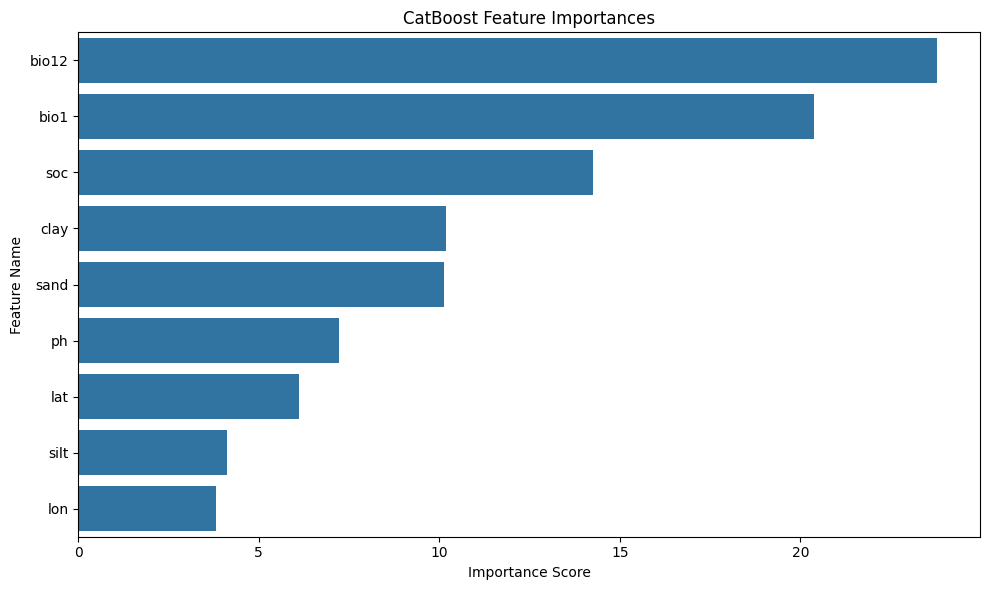

In [ ]:


# Get feature importances from the trained model
feature_importances = model.get_feature_importance()

# Get feature names from the training data
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort the DataFrame by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('CatBoost Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()


## Confusion Matrix Visualization

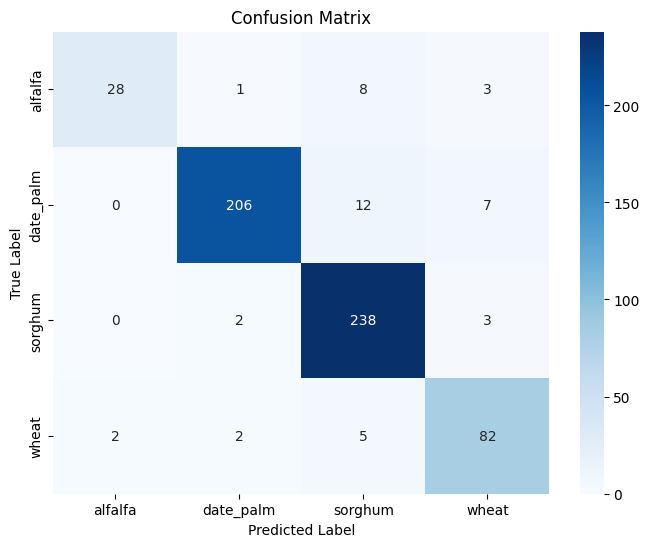

In [ ]:
# Convert predictions to a 1D array
y_pred_labels = [item[0] for item in y_pred] if y_pred.ndim > 1 else y_pred

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_labels)

# Get unique class labels from y_test and y_pred_labels
class_labels = sorted(list(set(y_pred_labels)))

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Irrigation Scheduling Model

In [ ]:
# Normalize features using MinMaxScaler
scaler = MinMaxScaler()
df[['temp_norm', 'rain_norm']] = scaler.fit_transform(df[['bio1', 'bio12']])

# Calculate soil drainage factor
df['soil_draining'] = df['sand'] / (df['sand'] + df['clay'])

# map crop water needs
crop_base = {
    "date_palm": 0.85,
    "alfalfa": 0.9,
    "sorghum": 0.6,
    "wheat": 0.45
}

df['crop_factor'] = df['best_crop'].map(crop_base)

# Compute irrigation score
df['irrigation_score'] = (
    df['temp_norm'] * 0.35 +
    (1 - df['rain_norm']) * 0.35 +
    (1 - df['soil_draining']) * 0.15 +
    df['crop_factor'] * 0.15
)

#  Convert score to categories
df['irrigation_need'] = pd.cut(
    df['irrigation_score'],
    bins=[0, 0.33, 0.66, 1],
    labels=['Low', 'Medium', 'High']
)

# Prepare features and target for ML
X_rand = df[['bio1', 'bio12', 'sand', 'silt', 'clay', 'soc', 'ph', 'crop_factor']]
y_rand= df['irrigation_need']

X_train_rand, X_test_rand, y_train_rand, y_test_rand = train_test_split(X_rand, y_rand, test_size=0.2, random_state=42)
model_rand = RandomForestClassifier(n_estimators=300, max_depth=14, class_weight='balanced')
model_rand.fit(X_train_rand, y_train_rand)

# Predict
y_pred_rand = model_rand.predict(X_test_rand)
print(classification_report(y_test_rand, y_pred_rand))

# Map irrigation need to weekly watering frequency
irrigation_schedule = {
    'Low': 2,      # Low need: 2 times per week
    'Medium': 4,
    'High': 6
}
df['weekly_irrigation'] = df['irrigation_need'].map(irrigation_schedule)

df

              precision    recall  f1-score   support

        High       0.99      0.94      0.97       198
         Low       1.00      1.00      1.00         4
      Medium       0.97      1.00      0.99       397

    accuracy                           0.98       599
   macro avg       0.99      0.98      0.98       599
weighted avg       0.98      0.98      0.98       599



,lon,lat,bio1,bio12,ph,sand,silt,clay,soc,best_crop,temp_norm,rain_norm,soil_draining,crop_factor,irrigation_score,irrigation_need,weekly_irrigation
0,48.213810,27.595989,25.751167,115.0,79,421,278,300,31,sorghum,0.649201,0.400000,0.583911,0.60,0.589634,Medium,4
1,41.090602,29.001198,22.198000,96.0,80,379,266,355,66,alfalfa,0.398348,0.330909,0.516349,0.90,0.581151,Medium,4
2,48.390390,21.916444,28.525333,66.0,81,493,357,150,42,date_palm,0.845057,0.221818,0.766719,0.85,0.730626,High,6
3,50.993206,21.137445,28.545334,59.0,80,542,321,137,45,date_palm,0.846469,0.196364,0.798233,0.85,0.735302,High,6
4,51.566302,22.644760,28.266000,65.0,80,542,317,141,46,date_palm,0.826748,0.218182,0.793558,0.85,0.721464,High,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2986,37.779933,29.644398,20.603834,39.0,81,391,345,264,37,wheat,0.285800,0.123636,0.596947,0.45,0.534715,Medium,4
2987,52.296268,20.980416,28.598833,67.0,80,573,308,119,40,date_palm,0.850246,0.225455,0.828035,0.85,0.721972,High,6
2988,46.659209,25.693226,25.161667,149.0,78,445,316,239,32,sorghum,0.607582,0.523636,0.650585,0.60,0.521793,Medium,4
2989,50.295256,23.420991,27.549500,67.0,79,520,318,162,44,date_palm,0.776163,0.225455,0.762463,0.85,0.705878,High,6


In [ ]:
# Generate daily irrigation schedule
days_of_week = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

def generate_weekly_schedule(times_per_week):
    schedule = ['No']*7
    if times_per_week == 0:
        return schedule
    # Spread watering days evenly across the week
    step = 7 // times_per_week
    for i in range(times_per_week):
        schedule[i*step] = 'Yes'
    return schedule

# Create separate DataFrame for weekly irrigation schedule
schedules = df['weekly_irrigation'].astype(int).apply(lambda x: generate_weekly_schedule(x))
weekly_schedule_df = pd.DataFrame(schedules.tolist(), columns=[f'irrigate_{day}' for day in days_of_week], index=df.index)

# crop info
weekly_schedule_df.insert(0, 'best_crop', df['best_crop'])
weekly_schedule_df.insert(1, 'irrigation_need', df['irrigation_need'])

# Count date_palm by irrigation need
date_palm_counts = df[df['best_crop'] == 'date_palm']['irrigation_need'].value_counts()
print(date_palm_counts)

weekly_schedule_df.head()

irrigation_need
High      930
Medium    194
Low         0
Name: count, dtype: int64


,best_crop,irrigation_need,irrigate_Mon,irrigate_Tue,irrigate_Wed,irrigate_Thu,irrigate_Fri,irrigate_Sat,irrigate_Sun
0,sorghum,Medium,Yes,Yes,Yes,Yes,No,No,No
1,alfalfa,Medium,Yes,Yes,Yes,Yes,No,No,No
2,date_palm,High,Yes,Yes,Yes,Yes,Yes,Yes,No
3,date_palm,High,Yes,Yes,Yes,Yes,Yes,Yes,No
4,date_palm,High,Yes,Yes,Yes,Yes,Yes,Yes,No


# InterFace


In [ ]:

feature_ranges = X.describe().T[['min','max']]


def encode_public_inputs(soil_type, rainfall_level, temp_level, ph_level):

    if soil_type == "Sandy": sand, silt, clay = 80, 10, 10
    elif soil_type == "Loamy": sand, silt, clay = 40, 40, 20
    else: sand, silt, clay = 20, 30, 50


    bio12_dict = {"Low": 300, "Medium": 800, "High": 1200}
    bio12 = bio12_dict[rainfall_level]


    bio1_dict = {"Low": 15, "Medium": 25, "High": 30}
    bio1 = bio1_dict[temp_level]


    ph_dict = {"Acidic": 5, "Neutral": 7, "Alkaline": 8}
    ph = ph_dict[ph_level]


    soc = 2


    return pd.DataFrame([[0,0,bio1,bio12,ph,sand,silt,clay,soc]],
                        columns=X.columns)

def predict_crop_public(soil_type, rainfall_level, temp_level, ph_level):
    input_df = encode_public_inputs(soil_type, rainfall_level, temp_level, ph_level)
    pred = str(model.predict(input_df)[0]).strip()

    html_output = f"""
    <div style='padding:15px; border-radius:10px; background-color:#d0f0c0;
                border:2px solid #4caf50; text-align:center; font-size:24px; font-weight:bold;'>
        Recommended Crop: {pred.upper()}
    </div>
    """
    return html_output

def predict_crop_expert(bio1, bio12, ph, sand, silt, clay, soc):
    input_df = pd.DataFrame([[0,0,bio1,bio12,ph,sand,silt,clay,soc]], columns=X.columns)
    pred = str(model.predict(input_df)[0]).strip()

    html_output = f"""
    <div style='padding:15px; border-radius:10px; background-color:#f0e68c;
                border:2px solid #ff9800; text-align:center; font-size:24px; font-weight:bold;'>
        Recommended Crop: {pred.upper()}
    </div>
    """
    return html_output



theme = gr.themes.Soft(primary_hue="green", secondary_hue="emerald", neutral_hue="gray")

with gr.Blocks(theme=theme) as demo:

    gr.Markdown("<h1 style='text-align:center;'> Saudi Smart Crop Recommendation System</h1>")
    gr.Markdown("<h3 style='text-align:center;'>AI-based Crop Prediction for Soil & Climate Conditions</h3>")

    # Simple Mode
    with gr.Tab(" Simple Mode"):
        gr.Markdown("### Choose your environmental conditions:")

        soil_type = gr.Dropdown(["Sandy","Loamy","Clay"], label="Soil Type")
        rainfall_level = gr.Dropdown(["Low","Medium","High"], label="Rainfall Level")
        temp_level = gr.Dropdown(["Low","Medium","High"], label="Temperature Level")
        ph_level = gr.Dropdown(["Acidic","Neutral","Alkaline"], label="Soil pH Level")

        output_public = gr.HTML()
        btn_public = gr.Button(" Predict Crop")
        btn_public.click(fn=predict_crop_public,
                         inputs=[soil_type, rainfall_level, temp_level, ph_level],
                         outputs=output_public)

    # Expert Mode
    with gr.Tab(" Expert Mode"):
        gr.Markdown("### Enter precise environmental values:")

        bio1 = gr.Number(label=f"Mean Annual Temperature (bio1) [{feature_ranges.loc['bio1','min']:.1f} - {feature_ranges.loc['bio1','max']:.1f}]")
        bio12 = gr.Number(label=f"Annual Rainfall (bio12) [{feature_ranges.loc['bio12','min']:.1f} - {feature_ranges.loc['bio12','max']:.1f}]")
        ph = gr.Number(label=f"Soil pH [{feature_ranges.loc['ph','min']:.1f} - {feature_ranges.loc['ph','max']:.1f}]")
        sand = gr.Number(label=f"Sand (%) [{feature_ranges.loc['sand','min']:.1f} - {feature_ranges.loc['sand','max']:.1f}]")
        silt = gr.Number(label=f"Silt (%) [{feature_ranges.loc['silt','min']:.1f} - {feature_ranges.loc['silt','max']:.1f}]")
        clay = gr.Number(label=f"Clay (%) [{feature_ranges.loc['clay','min']:.1f} - {feature_ranges.loc['clay','max']:.1f}]")
        soc = gr.Number(label=f"Soil Organic Carbon (SOC) [{feature_ranges.loc['soc','min']:.1f} - {feature_ranges.loc['soc','max']:.1f}]")

        output_expert = gr.HTML()
        btn_expert = gr.Button("  Predict Crop")
        btn_expert.click(fn=predict_crop_expert,
                         inputs=[bio1,bio12,ph,sand,silt,clay,soc],
                         outputs=output_expert)


demo.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e7831e204219d027da.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
